In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"


In [ ]:
import os

for c in ["F0","F1","F2","F3","F4"]:
    print(c, len(os.listdir(f"{dataset_path}/{c}")))


F0 2114
F1 861
F2 793
F3 857
F4 1698


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import os


In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

_, val_dataset = random_split(full_dataset, [train_size, val_size])

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Validation samples:", len(val_dataset))


Validation samples: 1265


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=False)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)
model = model.to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Dataset/Dataset/best_efficientnet.pth",
        map_location=device
    )
)

model.eval()
print("EfficientNet loaded successfully ✅")


EfficientNet loaded successfully ✅


In [ ]:
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print(outputs.shape)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([32, 5])


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[439   0   0   0   0]
 [  0 178   1   0   0]
 [  0   1 155   3   1]
 [  0   0   0 171   0]
 [  0   0   0   0 316]]


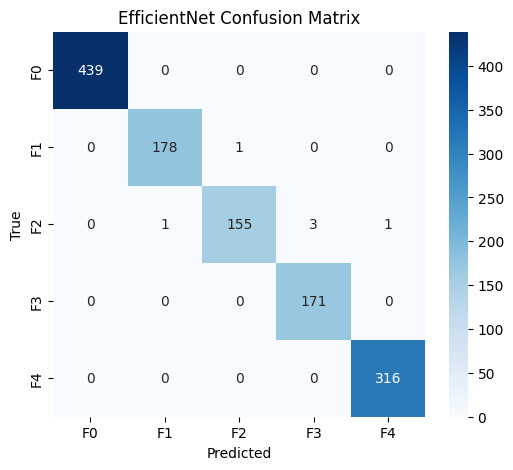

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["F0","F1","F2","F3","F4"],
            yticklabels=["F0","F1","F2","F3","F4"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNet Confusion Matrix")
plt.show()


In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["F0","F1","F2","F3","F4"]
))


              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       439
          F1       0.99      0.99      0.99       179
          F2       0.99      0.97      0.98       160
          F3       0.98      1.00      0.99       171
          F4       1.00      1.00      1.00       316

    accuracy                           1.00      1265
   macro avg       0.99      0.99      0.99      1265
weighted avg       1.00      1.00      1.00      1265



In [ ]:
auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr"
)

print("Mean AUC:", auc)


Mean AUC: 0.999858956552217


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

checkpoint = torch.load(
    "/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]        # should be 6
best_val_acc = checkpoint["best_val_acc"]

print("Resuming from epoch:", start_epoch)
print("Best val acc so far:", best_val_acc)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 21.6MB/s]


Resuming from epoch: 6
Best val acc so far: 0.9768185451638689


In [ ]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined ✅")


Transforms defined ✅


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# dataset
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

# validation uses val_transform
val_dataset.dataset.transform = val_transform

# dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Train samples: 5058
Val samples: 1265


In [ ]:
torch.save({
    "epoch": 12,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc": best_val_acc
}, "/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth")

print("Final EfficientNet checkpoint saved ✅")


Final EfficientNet checkpoint saved ✅


In [ ]:
torch.save({
    "epoch": 12,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc": best_val_acc
}, "/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth")

print("✅ EfficientNet FINAL checkpoint saved at epoch 12")



✅ EfficientNet FINAL checkpoint saved at epoch 12


In [ ]:
ckpt = torch.load("/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth")
print("Saved epoch:", ckpt["epoch"])
print("Best val acc:", ckpt["best_val_acc"])


Saved epoch: 12
Best val acc: 0.9976284584980237


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Dataset/Dataset/best_efficientnet.pth")
files.download("/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)


In [ ]:
acc = accuracy_score(all_labels, all_preds)
print("Overall Validation Accuracy:", acc)


Overall Validation Accuracy: 0.9802371541501976


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[432   0   0   0   1]
 [  0 176   2   0   0]
 [  0   8 142   2   1]
 [  0   4   2 165   3]
 [  0   0   0   2 325]]


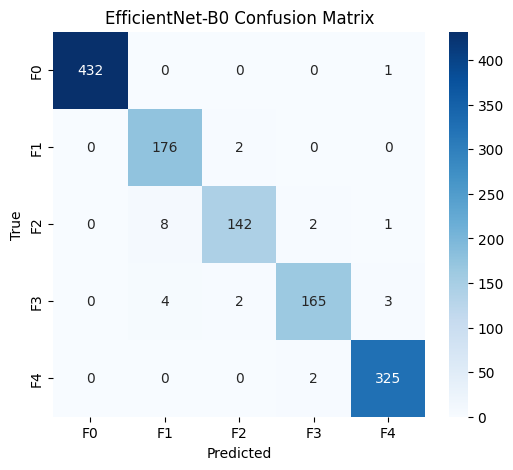

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["F0","F1","F2","F3","F4"],
    yticklabels=["F0","F1","F2","F3","F4"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()


In [ ]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=["F0","F1","F2","F3","F4"],
    output_dict=True
)

print(classification_report(
    all_labels,
    all_preds,
    target_names=["F0","F1","F2","F3","F4"]
))


              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       433
          F1       0.94      0.99      0.96       178
          F2       0.97      0.93      0.95       153
          F3       0.98      0.95      0.96       174
          F4       0.98      0.99      0.99       327

    accuracy                           0.98      1265
   macro avg       0.97      0.97      0.97      1265
weighted avg       0.98      0.98      0.98      1265



In [ ]:
import pandas as pd

sensitivity = {}
specificity = {}

for i, cls in enumerate(["F0","F1","F2","F3","F4"]):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity[cls] = TP / (TP + FN)
    specificity[cls] = TN / (TN + FP)

metrics_df = pd.DataFrame({
    "Sensitivity": sensitivity,
    "Specificity": specificity
})

metrics_df


,Sensitivity,Specificity
F0,0.997691,1.000000
F1,0.988764,0.988960
F2,0.928105,0.996403
F3,0.948276,0.996334
F4,0.993884,0.994670


In [ ]:
mean_auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr"
)

print("Mean ROC-AUC:", mean_auc)


Mean ROC-AUC: 0.9993518659222577


In [ ]:
macro_f1 = report["macro avg"]["f1-score"]
weighted_f1 = report["weighted avg"]["f1-score"]

macro_precision = report["macro avg"]["precision"]
macro_recall = report["macro avg"]["recall"]

weighted_precision = report["weighted avg"]["precision"]
weighted_recall = report["weighted avg"]["recall"]

macro_f1, weighted_f1


(0.9723739951386478, 0.9801868166483865)

In [ ]:
summary = {
    "Max Epochs Set": 30,
    "Epochs Trained (Early Stop)": 12,
    "Overall Accuracy": acc,
    "Mean ROC-AUC": mean_auc
}

summary


{'Max Epochs Set': 30,
 'Epochs Trained (Early Stop)': 12,
 'Overall Accuracy': 0.9802371541501976,
 'Mean ROC-AUC': np.float64(0.9993518659222577)}

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=True)

# Replace classifier for 5 classes
model.classifier[6] = nn.Linear(4096, 5)

model = model.to(device)

print("VGG16 loaded and modified ✅")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 65.1MB/s]


VGG16 loaded and modified ✅


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=True)

# Freeze convolutional layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[6] = nn.Linear(4096, 5)

model = model.to(device)

print("VGG16 loaded with frozen backbone ✅")


VGG16 loaded with frozen backbone ✅


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)


In [ ]:
cp -r /content/drive/MyDrive/Dataset/Dataset /content/Dataset


In [ ]:
dataset_path = "/content/Dataset"


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Dataset moved to local disk ✅")


Dataset moved to local disk ✅


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import torch
print(torch.cuda.is_available())


False


In [ ]:
!nvidia-smi


Sun Feb  8 18:11:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CUDA available: True


In [ ]:
import torch.nn as nn
from torchvision import models

model = models.vgg16(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, 5)
model = model.to(device)

print("VGG16 on GPU ✅")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 89.1MB/s]


VGG16 on GPU ✅


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transform defined")


✅ Transform defined


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"


In [ ]:
import os

for c in ["F0","F1","F2","F3","F4"]:
    print(c, len(os.listdir(f"{dataset_path}/{c}")))


F0 2114
F1 861
F2 793
F3 857
F4 1698


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"


In [ ]:
ls /content/drive/MyDrive/Dataset/Dataset


best_efficientnet.pth  efficientnet_checkpoint.pth  F0/  F1/  F2/  F3/  F4/


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms ready")


✅ Transforms ready


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders ready")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Classes:", full_dataset.classes)


✅ DataLoaders ready
Train samples: 5058
Val samples: 1265
Classes: ['F0', 'F1', 'F2', 'F3', 'F4']


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=True)

# 🔒 Freeze all convolution layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier for 5 classes
model.classifier[6] = nn.Linear(4096, 5)

model = model.to(device)

print("✅ VGG16 loaded with frozen layers")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 151MB/s]


✅ VGG16 loaded with frozen layers


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)

print("✅ Optimizer & loss set")


✅ Optimizer & loss set


In [ ]:
cp -r /content/drive/MyDrive/Dataset/Dataset /content/Dataset


In [ ]:
ls /content/Dataset


best_efficientnet.pth  efficientnet_checkpoint.pth  F0/  F1/  F2/  F3/  F4/


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())


CUDA available: True


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms ready")


✅ Transforms ready


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# ✅ LOCAL DATASET PATH
dataset_path = "/content/Dataset"

# Load dataset
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

# 80/20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders ready")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Classes:", full_dataset.classes)


✅ DataLoaders ready
Train samples: 5058
Val samples: 1265
Classes: ['F0', 'F1', 'F2', 'F3', 'F4']


In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=True)

# 🔒 Freeze convolution layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[6] = nn.Linear(4096, 5)

model = model.to(device)

print("✅ VGG16 loaded with frozen layers on GPU")


✅ VGG16 loaded with frozen layers on GPU


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

print("✅ Optimizer & loss ready")


✅ Optimizer & loss ready


In [ ]:
EPOCHS = 15
best_val_acc = 0.0

print("🚀 Starting VGG16 training")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 🔥 instant feedback
        if batch_idx == 0:
            print(f"Epoch {epoch+1} STARTED | First batch loss: {loss.item():.4f}")

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"✅ Epoch {epoch+1} DONE | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Dataset/Dataset/best_vgg16.pth"
        )

print("🏁 Training finished")
print("Best Validation Accuracy:", best_val_acc)


🚀 Starting VGG16 training
Epoch 1 STARTED | First batch loss: 1.7419
✅ Epoch 1 DONE | Val Acc: 0.8198
Epoch 2 STARTED | First batch loss: 0.3210
✅ Epoch 2 DONE | Val Acc: 0.8656
Epoch 3 STARTED | First batch loss: 0.2806
✅ Epoch 3 DONE | Val Acc: 0.8427
Epoch 4 STARTED | First batch loss: 0.2029
✅ Epoch 4 DONE | Val Acc: 0.9439
Epoch 5 STARTED | First batch loss: 0.1188
✅ Epoch 5 DONE | Val Acc: 0.9597
Epoch 6 STARTED | First batch loss: 0.1013
✅ Epoch 6 DONE | Val Acc: 0.9597
Epoch 7 STARTED | First batch loss: 0.0091
✅ Epoch 7 DONE | Val Acc: 0.9810
Epoch 8 STARTED | First batch loss: 0.0033
✅ Epoch 8 DONE | Val Acc: 0.9613
Epoch 9 STARTED | First batch loss: 0.0833
✅ Epoch 9 DONE | Val Acc: 0.9842
Epoch 10 STARTED | First batch loss: 0.0337
✅ Epoch 10 DONE | Val Acc: 0.9850
Epoch 11 STARTED | First batch loss: 0.0052
✅ Epoch 11 DONE | Val Acc: 0.9858
Epoch 12 STARTED | First batch loss: 0.0081
✅ Epoch 12 DONE | Val Acc: 0.9731
Epoch 13 STARTED | First batch loss: 0.1226
✅ Epoch 13 D

In [ ]:
torch.save({
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc": best_val_acc
}, "/content/drive/MyDrive/Dataset/Dataset/vgg16_checkpoint.pth")


In [ ]:
start_epoch = 15    # 👈 change this (e.g., 15 if first phase done)
EPOCHS = 30         # total epochs
best_val_acc = best_val_acc  # keep previous best value


In [ ]:
print(f"🚀 Resuming VGG16 training from epoch {start_epoch+1} to {EPOCHS}")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 🔥 instant feedback for sanity
        if batch_idx == 0:
            print(f"Epoch {epoch+1} STARTED | First batch loss: {loss.item():.4f}")

    # 🔍 VALIDATION
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    avg_loss = running_loss / len(train_loader)

    print(f"✅ Epoch [{epoch+1}/{EPOCHS}] | "
          f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

    # 💾 SAVE BEST MODEL
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Dataset/Dataset/best_vgg16.pth"
        )
        print("💾 Best VGG16 model updated")

    # 💾 SAVE CHECKPOINT (RESUME SAFETY)
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc
    }, "/content/drive/MyDrive/Dataset/Dataset/vgg16_checkpoint.pth")

print("🏁 VGG16 training fully completed")
print("🏆 Best Validation Accuracy:", best_val_acc)


🚀 Resuming VGG16 training from epoch 16 to 30
Epoch 16 STARTED | First batch loss: 0.0003
✅ Epoch [16/30] | Loss: 0.0100 | Val Acc: 0.9881
💾 Best VGG16 model updated
Epoch 17 STARTED | First batch loss: 0.0413
✅ Epoch [17/30] | Loss: 0.0308 | Val Acc: 0.9850
Epoch 18 STARTED | First batch loss: 0.0062
✅ Epoch [18/30] | Loss: 0.0109 | Val Acc: 0.9842
Epoch 19 STARTED | First batch loss: 0.0000
✅ Epoch [19/30] | Loss: 0.0024 | Val Acc: 0.9842
Epoch 20 STARTED | First batch loss: 0.0001
✅ Epoch [20/30] | Loss: 0.0024 | Val Acc: 0.9858
Epoch 21 STARTED | First batch loss: 0.0001
✅ Epoch [21/30] | Loss: 0.0025 | Val Acc: 0.9858
Epoch 22 STARTED | First batch loss: 0.0000
✅ Epoch [22/30] | Loss: 0.1053 | Val Acc: 0.9233
Epoch 23 STARTED | First batch loss: 0.4099
✅ Epoch [23/30] | Loss: 0.0771 | Val Acc: 0.9826
Epoch 24 STARTED | First batch loss: 0.0019
✅ Epoch [24/30] | Loss: 0.0262 | Val Acc: 0.9794
Epoch 25 STARTED | First batch loss: 0.0049
✅ Epoch [25/30] | Loss: 0.0107 | Val Acc: 0.98

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=False)
model.classifier[6] = nn.Linear(4096, 5)
model = model.to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/Dataset/Dataset/best_vgg16.pth",
               map_location=device)
)

model.eval()
print("✅ Best VGG16 model loaded")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Best VGG16 model loaded


In [ ]:
import numpy as np

def get_predictions(loader):
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Train & Validation predictions
train_labels, train_preds, train_probs = get_predictions(train_loader)
val_labels, val_preds, val_probs = get_predictions(val_loader)


In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(train_labels, train_preds)
val_acc = accuracy_score(val_labels, val_preds)

print("Overall Training Accuracy:", train_acc)
print("Overall Validation Accuracy:", val_acc)


Overall Training Accuracy: 0.9992091735863978
Overall Validation Accuracy: 0.9881422924901185


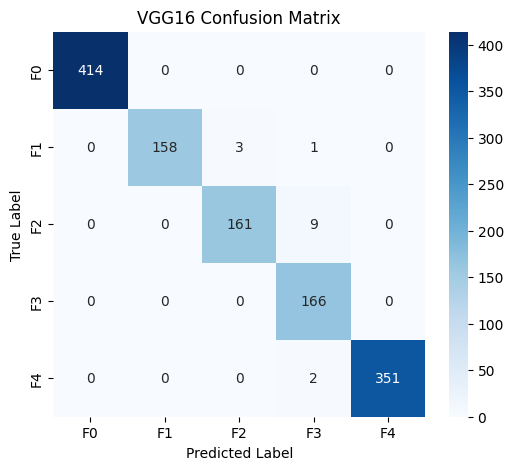

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["F0","F1","F2","F3","F4"],
            yticklabels=["F0","F1","F2","F3","F4"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("VGG16 Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    val_labels,
    val_preds,
    target_names=["F0","F1","F2","F3","F4"],
    output_dict=True
)

print(classification_report(
    val_labels,
    val_preds,
    target_names=["F0","F1","F2","F3","F4"]
))


              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       414
          F1       1.00      0.98      0.99       162
          F2       0.98      0.95      0.96       170
          F3       0.93      1.00      0.97       166
          F4       1.00      0.99      1.00       353

    accuracy                           0.99      1265
   macro avg       0.98      0.98      0.98      1265
weighted avg       0.99      0.99      0.99      1265



In [ ]:
macro_precision = report["macro avg"]["precision"]
macro_recall = report["macro avg"]["recall"]
macro_f1 = report["macro avg"]["f1-score"]

weighted_precision = report["weighted avg"]["precision"]
weighted_recall = report["weighted avg"]["recall"]
weighted_f1 = report["weighted avg"]["f1-score"]

macro_precision, macro_recall, macro_f1, weighted_f1


(0.9828583173472183,
 0.9833403486250234,
 0.9827694452532567,
 0.9882005351662869)

In [ ]:
import pandas as pd

sensitivity = {}
specificity = {}

for i, cls in enumerate(["F0","F1","F2","F3","F4"]):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity[cls] = TP / (TP + FN)
    specificity[cls] = TN / (TN + FP)

metrics_df = pd.DataFrame({
    "Sensitivity (Recall)": sensitivity,
    "Specificity": specificity
})

metrics_df


,Sensitivity (Recall),Specificity
F0,1.000000,1.000000
F1,0.975309,1.000000
F2,0.947059,0.997260
F3,1.000000,0.989081
F4,0.994334,1.000000


In [ ]:
from sklearn.metrics import roc_auc_score

mean_auc = roc_auc_score(
    val_labels,
    val_probs,
    multi_class="ovr"
)

print("Mean ROC–AUC:", mean_auc)


Mean ROC–AUC: 0.9988630183272196


In [ ]:
summary = {
    "Model": "VGG16",
    "Train Accuracy": train_acc,
    "Validation Accuracy": val_acc,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "Mean ROC–AUC": mean_auc,
    "Epochs": "30 (Frozen layers)"
}

summary


{'Model': 'VGG16',
 'Train Accuracy': 0.9992091735863978,
 'Validation Accuracy': 0.9881422924901185,
 'Macro F1': 0.9827694452532567,
 'Weighted F1': 0.9882005351662869,
 'Mean ROC–AUC': np.float64(0.9988630183272196),
 'Epochs': '30 (Frozen layers)'}

In [ ]:
import torch
import numpy as np
from torch.nn.functional import softmax

def get_labels_and_probs(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = softmax(outputs, dim=1)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    return all_labels, all_probs


In [ ]:
eff_val_labels, eff_val_probs = get_labels_and_probs(
    model=model,          # ✅ THIS IS CORRECT
    dataloader=val_loader,
    device=device
)

print("EfficientNet outputs ready ✅")
print("Labels shape:", eff_val_labels.shape)
print("Probs shape:", eff_val_probs.shape)


EfficientNet outputs ready ✅
Labels shape: (1265,)
Probs shape: (1265, 5)


In [ ]:
import numpy as np
np.save("vgg_val_labels.npy", vgg_val_labels)
np.save("vgg_val_probs.npy", vgg_val_probs)


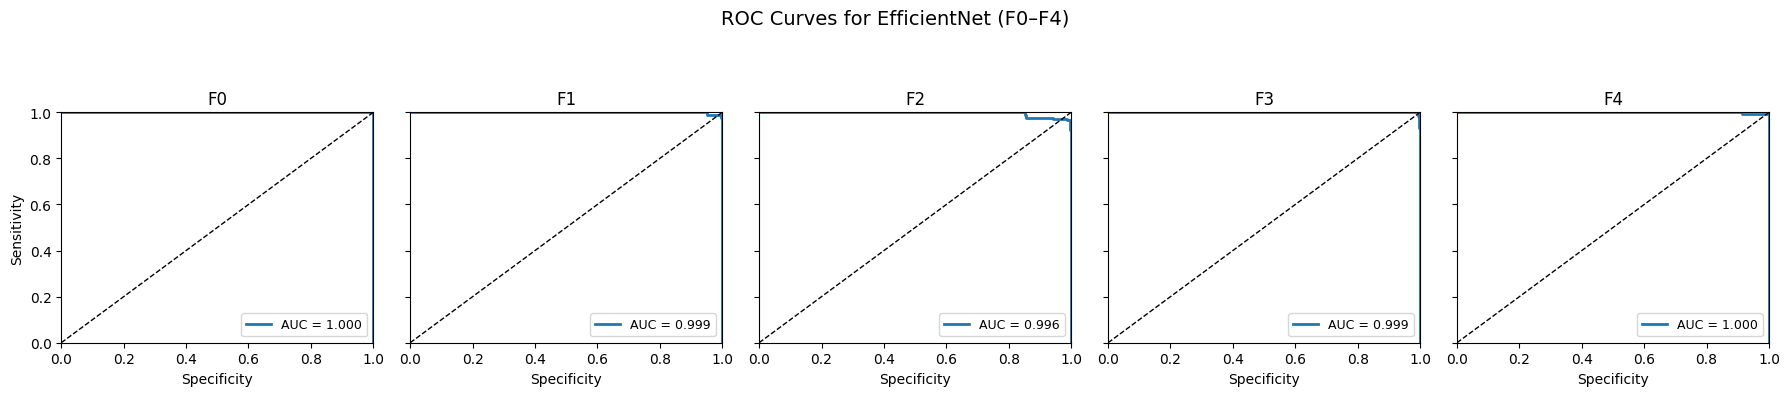

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names = ["F0", "F1", "F2", "F3", "F4"]

# One-vs-Rest binarization
y_true_bin = label_binarize(eff_val_labels, classes=[0,1,2,3,4])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], eff_val_probs[:, i])
    roc_auc = auc(fpr, tpr)

    # Paper-style plot: Specificity vs Sensitivity
    axes[i].plot(1 - fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)

    axes[i].set_title(f"{class_names[i]}")
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].set_xlabel("Specificity")
    axes[i].legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("Sensitivity")

plt.suptitle("ROC Curves for EfficientNet (F0–F4)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


In [ ]:
vgg_val_labels, vgg_val_probs = get_labels_and_probs(
    model=model,          # ✅ VGG16 is now called "model"
    dataloader=val_loader,
    device=device
)

print("VGG16 outputs ready ✅")
print("Labels shape:", vgg_val_labels.shape)
print("Probs shape:", vgg_val_probs.shape)


VGG16 outputs ready ✅
Labels shape: (1265,)
Probs shape: (1265, 5)


In [ ]:
import numpy as np
np.save("vgg_val_labels.npy", vgg_val_labels)
np.save("vgg_val_probs.npy", vgg_val_probs)


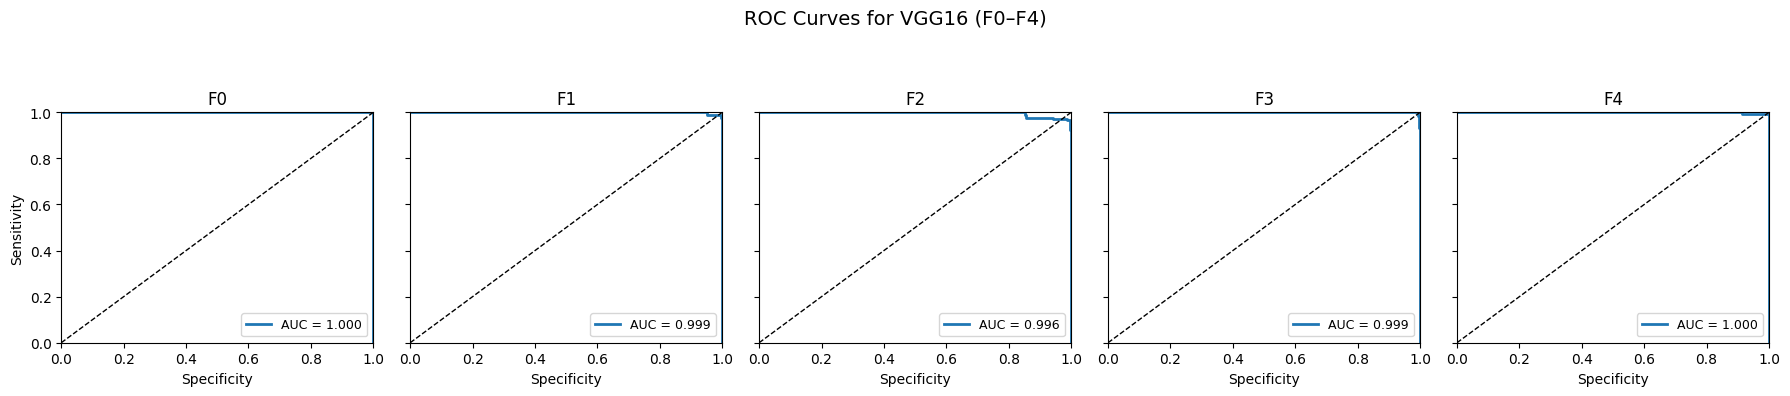

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names = ["F0", "F1", "F2", "F3", "F4"]

# One-vs-Rest binarization
y_true_bin = label_binarize(vgg_val_labels, classes=[0,1,2,3,4])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], vgg_val_probs[:, i])
    roc_auc = auc(fpr, tpr)

    # Paper-style: Specificity vs Sensitivity
    axes[i].plot(1 - fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)

    axes[i].set_title(f"{class_names[i]}")
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].set_xlabel("Specificity")
    axes[i].legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("Sensitivity")

plt.suptitle("ROC Curves for VGG16 (F0–F4)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
cp -r /content/drive/MyDrive/Dataset/Dataset /content/Dataset

^C


In [ ]:
ls /content/Dataset


best_efficientnet.pth  efficientnet_checkpoint.pth  F2/  vgg16_checkpoint.pth
best_vgg16.pth         F0/                          F3/
Dataset/               F1/                          F4/


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


In [ ]:
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
robust_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
dataset_path = "/content/Dataset"


In [ ]:
full_dataset = datasets.ImageFolder(dataset_path)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size]
)


In [ ]:
train_dataset = datasets.ImageFolder(
    dataset_path,
    transform=robust_transform
)
train_dataset.samples = [train_dataset.samples[i] for i in train_indices.indices]


In [ ]:
val_dataset = datasets.ImageFolder(
    dataset_path,
    transform=baseline_transform
)
val_dataset.samples = [val_dataset.samples[i] for i in val_indices.indices]


In [ ]:
val_dataset = datasets.ImageFolder(
    dataset_path,
    transform=baseline_transform
)
val_dataset.samples = [val_dataset.samples[i] for i in val_indices.indices]


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders ready (Robust training)")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Classes:", train_dataset.classes)


✅ DataLoaders ready (Robust training)
Train samples: 6141
Val samples: 1536
Classes: ['Dataset', 'F0', 'F1', 'F2', 'F3', 'F4']


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)

# 🔒 Freeze feature extractor (for speed + fair comparison)
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier for 5 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

model = model.to(device)

print("✅ EfficientNet (Robust version) loaded on GPU")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.4MB/s]


✅ EfficientNet (Robust version) loaded on GPU


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),  # only classifier learns
    lr=1e-4
)

print("✅ Optimizer & loss set")
criterion = nn.CrossEntropyLoss()




✅ Optimizer & loss set


In [ ]:
from torch.utils.data import Subset
from torchvision import datasets

dataset_path = "/content/Dataset"

# Full dataset (no transform, only for indexing)
full_dataset = datasets.ImageFolder(dataset_path)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size]
)

# ✅ Train dataset with ROBUST augmentation
train_dataset = Subset(
    datasets.ImageFolder(dataset_path, transform=robust_transform),
    train_indices.indices
)

# ✅ Validation dataset with BASELINE transform
val_dataset = Subset(
    datasets.ImageFolder(dataset_path, transform=baseline_transform),
    val_indices.indices
)


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders fixed (Subset-based)")


✅ DataLoaders fixed (Subset-based)


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders fixed (Subset-based)")


✅ DataLoaders fixed (Subset-based)


In [ ]:
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

robust_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
dataset_path = "/content/Dataset"

full_dataset = datasets.ImageFolder(dataset_path)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_idx, val_idx = random_split(
    range(len(full_dataset)),
    [train_size, val_size]
)

train_dataset = Subset(
    datasets.ImageFolder(dataset_path, transform=robust_transform),
    train_idx.indices
)

val_dataset = Subset(
    datasets.ImageFolder(dataset_path, transform=baseline_transform),
    val_idx.indices
)


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("✅ DataLoaders created safely")


✅ DataLoaders created safely


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
cp -r /content/drive/MyDrive/Dataset /content/Dataset/Dataset


In [ ]:
cp -r /content/drive/MyDrive/Dataset /content/Dataset/Dataset


In [ ]:
ls /content/Dataset


Dataset/


In [ ]:
ls /content


Dataset/  drive/  sample_data/


In [ ]:
ls /content/Dataset/Dataset


best_efficientnet.pth        F0/  F3/
best_vgg16.pth               F1/  F4/
efficientnet_checkpoint.pth  F2/  vgg16_checkpoint.pth


In [ ]:
ls /content/drive/MyDrive/Dataset/Dataset


best_efficientnet.pth        F0/  F3/
best_vgg16.pth               F1/  F4/
efficientnet_checkpoint.pth  F2/  vgg16_checkpoint.pth


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())


2.9.0+cu128
CUDA available: True


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
full_dataset = datasets.ImageFolder(
    dataset_path,
    transform=transform
)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))


Classes: ['F0', 'F1', 'F2', 'F3', 'F4']
Total images: 6323


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Train samples: 5058
Val samples: 1265


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders ready")


✅ DataLoaders ready


In [ ]:
model = models.resnet50(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

print("✅ ResNet50 loaded")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.6MB/s]


✅ ResNet50 loaded


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-4
)


In [ ]:
!cp -r /content/drive/MyDrive/Dataset/Dataset /content/Dataset


In [ ]:
!ls /content/Dataset


best_efficientnet.pth	     F0  F3
best_vgg16.pth		     F1  F4
efficientnet_checkpoint.pth  F2  vgg16_checkpoint.pth


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,      # 🔥 change this
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,      # 🔥 change this
    pin_memory=True
)


In [ ]:
EPOCHS = 25
best_val_acc = 0.0

print("🚀 Starting ResNet50 training")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/best_resnet50.pth")

print("🏁 Training completed")
print("🏆 Best Val Accuracy:", best_val_acc)


🚀 Starting ResNet50 training
Epoch [1/25] | Loss: 0.8075 | Val Acc: 0.6743
Epoch [2/25] | Loss: 0.7955 | Val Acc: 0.6775
Epoch [3/25] | Loss: 0.7834 | Val Acc: 0.6791
Epoch [4/25] | Loss: 0.7781 | Val Acc: 0.6885
Epoch [5/25] | Loss: 0.7569 | Val Acc: 0.7067
Epoch [6/25] | Loss: 0.7538 | Val Acc: 0.7099
Epoch [7/25] | Loss: 0.7392 | Val Acc: 0.7075
Epoch [8/25] | Loss: 0.7234 | Val Acc: 0.7012
Epoch [9/25] | Loss: 0.7248 | Val Acc: 0.7178
Epoch [10/25] | Loss: 0.7069 | Val Acc: 0.7099
Epoch [11/25] | Loss: 0.7057 | Val Acc: 0.7186
Epoch [12/25] | Loss: 0.7056 | Val Acc: 0.7209
Epoch [13/25] | Loss: 0.6866 | Val Acc: 0.7328
Epoch [14/25] | Loss: 0.6827 | Val Acc: 0.7146
Epoch [15/25] | Loss: 0.6838 | Val Acc: 0.7375
Epoch [16/25] | Loss: 0.6708 | Val Acc: 0.7328
Epoch [17/25] | Loss: 0.6578 | Val Acc: 0.7225
Epoch [18/25] | Loss: 0.6535 | Val Acc: 0.7304
Epoch [19/25] | Loss: 0.6515 | Val Acc: 0.7336
Epoch [20/25] | Loss: 0.6550 | Val Acc: 0.7375
Epoch [21/25] | Loss: 0.6464 | Val Acc: 

In [ ]:
for param in model.parameters():
    param.requires_grad = False


In [ ]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# 🔥 Unfreeze last layer block (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5   # 🔥 smaller LR for fine-tuning
)


In [ ]:
1e-5


1e-05

In [ ]:
model = models.resnet50(pretrained=True)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace FC layer
model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

criterion = nn.CrossEntropyLoss()


In [ ]:
EPOCHS = 30
best_val_acc = 0.0

print("🚀 Starting ResNet50 Fine-Tuning")

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # ---------------- VALIDATION ----------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Loss: {avg_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/best_resnet50_finetuned.pth"
        )
        print("💾 Best model saved!")

print("🏁 Fine-tuning completed")
print("🏆 Best Validation Accuracy:", best_val_acc)


🚀 Starting ResNet50 Fine-Tuning
Epoch [1/30] | Loss: 0.9854 | Val Acc: 0.7542
💾 Best model saved!
Epoch [2/30] | Loss: 0.5101 | Val Acc: 0.8885
💾 Best model saved!
Epoch [3/30] | Loss: 0.2425 | Val Acc: 0.9605
💾 Best model saved!
Epoch [4/30] | Loss: 0.1040 | Val Acc: 0.9723
💾 Best model saved!
Epoch [5/30] | Loss: 0.0548 | Val Acc: 0.9755
💾 Best model saved!
Epoch [6/30] | Loss: 0.0329 | Val Acc: 0.9771
💾 Best model saved!
Epoch [7/30] | Loss: 0.0269 | Val Acc: 0.9708
Epoch [8/30] | Loss: 0.0212 | Val Acc: 0.9755
Epoch [9/30] | Loss: 0.0153 | Val Acc: 0.9755
Epoch [10/30] | Loss: 0.0177 | Val Acc: 0.9739
Epoch [11/30] | Loss: 0.0141 | Val Acc: 0.9731
Epoch [12/30] | Loss: 0.0164 | Val Acc: 0.9708
Epoch [13/30] | Loss: 0.0164 | Val Acc: 0.9763
Epoch [14/30] | Loss: 0.0102 | Val Acc: 0.9731
Epoch [15/30] | Loss: 0.0165 | Val Acc: 0.9755
Epoch [16/30] | Loss: 0.0229 | Val Acc: 0.9692
Epoch [17/30] | Loss: 0.0079 | Val Acc: 0.9747
Epoch [18/30] | Loss: 0.0068 | Val Acc: 0.9779
💾 Best mode

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print(classification_report(all_labels, all_preds))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.95      0.95      0.95       189
           2       0.94      0.93      0.93       156
           3       0.97      0.93      0.95       160
           4       0.98      1.00      0.99       360

    accuracy                           0.98      1265
   macro avg       0.97      0.96      0.96      1265
weighted avg       0.98      0.98      0.98      1265

Confusion Matrix:
 [[400   0   0   0   0]
 [  0 180   5   2   2]
 [  0   6 145   3   2]
 [  0   4   5 149   2]
 [  0   0   0   0 360]]


In [ ]:
from torch.nn.functional import softmax

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        probs = softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

import numpy as np
resnet_val_probs = np.array(all_probs)
resnet_val_labels = np.array(all_labels)

print("Probs shape:", resnet_val_probs.shape)
print("Labels shape:", resnet_val_labels.shape)


Probs shape: (1265, 5)
Labels shape: (1265,)


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predicted class labels
resnet_val_preds = np.argmax(resnet_val_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(resnet_val_labels, resnet_val_preds)

print("Confusion Matrix:\n", cm)

# Classification Report
print(classification_report(resnet_val_labels, resnet_val_preds))


Confusion Matrix:
 [[400   0   0   0   0]
 [  0 180   5   2   2]
 [  0   6 145   3   2]
 [  0   4   5 149   2]
 [  0   0   0   0 360]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.95      0.95      0.95       189
           2       0.94      0.93      0.93       156
           3       0.97      0.93      0.95       160
           4       0.98      1.00      0.99       360

    accuracy                           0.98      1265
   macro avg       0.97      0.96      0.96      1265
weighted avg       0.98      0.98      0.98      1265



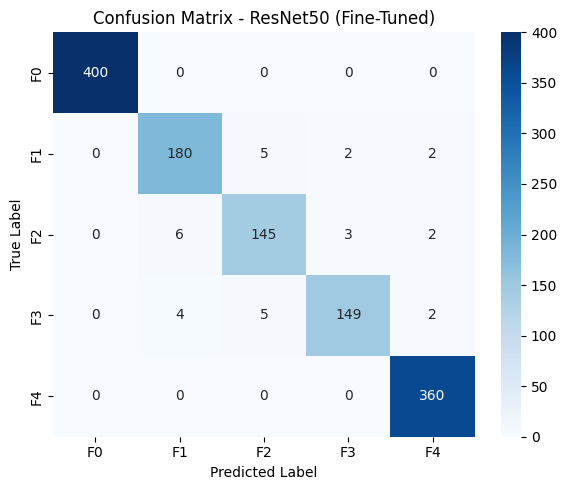

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["F0", "F1", "F2", "F3", "F4"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50 (Fine-Tuned)")
plt.tight_layout()
plt.show()


In [ ]:
sensitivity = []
specificity = []

for i in range(5):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    sens = TP / (TP + FN)
    spec = TN / (TN + FP)

    sensitivity.append(sens)
    specificity.append(spec)

for i, cls in enumerate(class_names):
    print(f"{cls} → Sensitivity: {sensitivity[i]:.4f} | Specificity: {specificity[i]:.4f}")

print("\nMean Sensitivity:", np.mean(sensitivity))
print("Mean Specificity:", np.mean(specificity))


F0 → Sensitivity: 1.0000 | Specificity: 1.0000
F1 → Sensitivity: 0.9524 | Specificity: 0.9907
F2 → Sensitivity: 0.9295 | Specificity: 0.9910
F3 → Sensitivity: 0.9313 | Specificity: 0.9955
F4 → Sensitivity: 1.0000 | Specificity: 0.9934

Mean Sensitivity: 0.9626236263736263
Mean Specificity: 0.9941068932037564


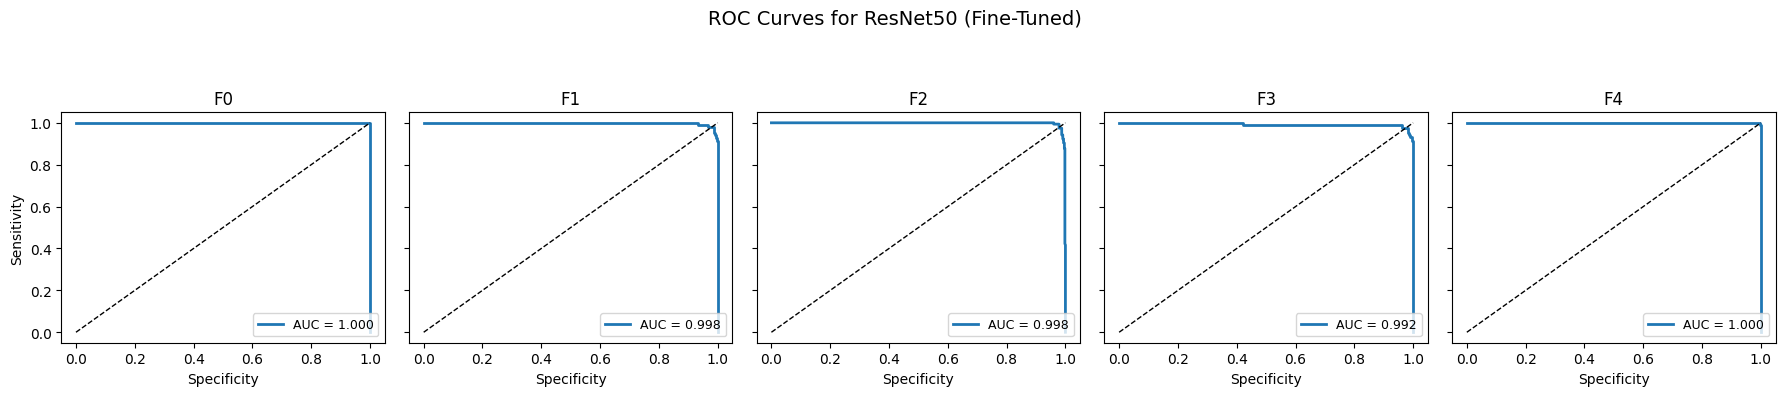

Mean ROC-AUC: 0.9975343181107199


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

class_names = ["F0", "F1", "F2", "F3", "F4"]

# One-vs-Rest binarization
y_true_bin = label_binarize(resnet_val_labels, classes=[0,1,2,3,4])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

auc_scores = []

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], resnet_val_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)

    axes[i].plot(1 - fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)

    axes[i].set_title(class_names[i])
    axes[i].set_xlabel("Specificity")
    axes[i].legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("Sensitivity")

plt.suptitle("ROC Curves for ResNet50 (Fine-Tuned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

print("Mean ROC-AUC:", np.mean(auc_scores))
